In [30]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
import optuna
import matplotlib.pyplot as plt


In [31]:
torch.manual_seed(42)

In [32]:
df = pd.read_csv("/Users/anandsharma/Documents/PhD/LearnML/CampusX/Datasets/fashionmnist/versions/4/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: mps


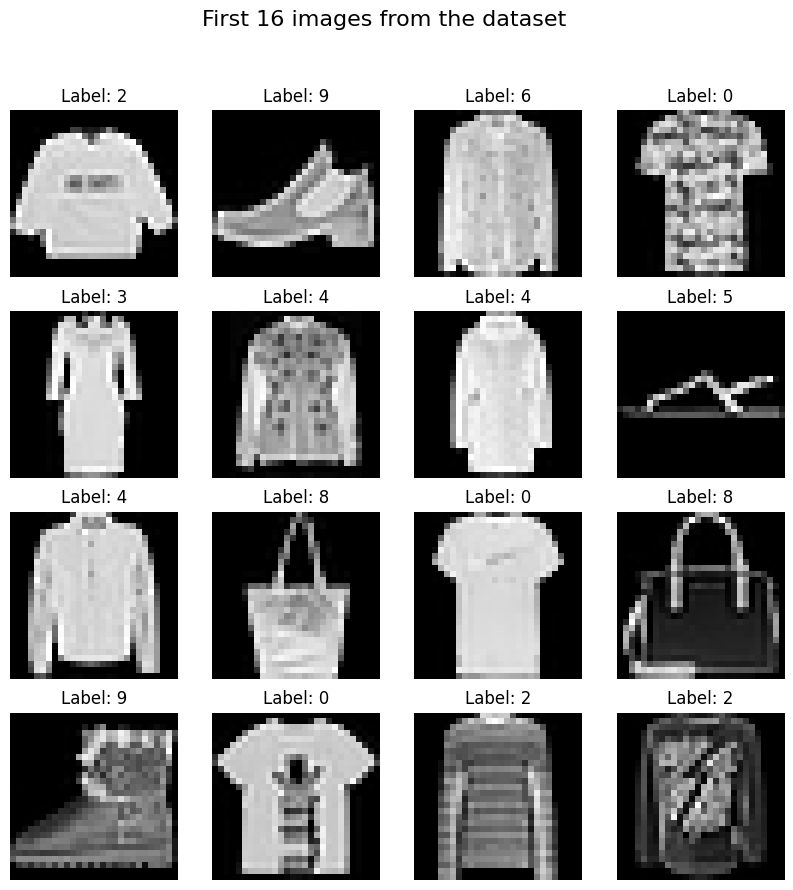

In [34]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images from the dataset", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    image = df.iloc[i, 1:].values.reshape(28, 28)
    label = df.iloc[i, 0]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

In [35]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Scaling the data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [38]:
# Create CustomDataset class

class CustomDataset(Dataset):

    def __init__(self, features, labels): 
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


In [39]:
# Create train and test datasets objects
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [40]:
# Cretate train and test dataloaders
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True) #, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False) #, pin_memory=True)

In [41]:
len(train_loader), len(test_loader)

(94, 24)

In [42]:
class MyNN(nn.Module): 

    def __init__(self, input_dimension, output_dimension, num_hidden_layers, neurons_per_layer, dropout_rate):
        super().__init__()
        layers = []

        for i in range(num_hidden_layers):
            if i == 0:
                layers.append(nn.Linear(input_dimension, neurons_per_layer))
            else:
                layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

        layers.append(nn.Linear(neurons_per_layer, output_dimension))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)   
    

In [43]:
# Objective function for Optuna

def objective(trial):

    # next hyperparameters values from the search space
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
    epochs = trial.suggest_int("epochs", 10, 50, step=10)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["SGD", "Adam", "RMSprop"])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)


    # Cretate train and test dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) #, pin_memory=True)
    # model init
    input_dimension = 784
    output_dimension = 10

    model = MyNN(input_dimension, output_dimension, num_hidden_layers, neurons_per_layer, dropout_rate)
    model.to(device)

    # params init
    #learning_rate = 0.01
    #epochs = 50

    criterion = nn.CrossEntropyLoss()

    # optimizer selection
    #optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else: 
        optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)


    # training loop
    for epoch in range(epochs):

        #model.train()

        for batch_idx, batch in enumerate(train_loader):

            X_batch, y_batch = batch
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()



    # evaluation loop
    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():
        for batch in test_loader:
            batch_features, batch_labels = batch
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.shape[0]
            correct += (predicted == batch_labels).sum().item()
        
        accuracy = correct / total

    return accuracy

In [47]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

[I 2026-04-12 02:00:23,979] A new study created in memory with name: no-name-b90e6d1e-5371-468a-ac47-8e3d6a408468
[I 2026-04-12 02:00:52,235] Trial 0 finished with value: 0.8563333333333333 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 128, 'epochs': 40, 'learning_rate': 0.0024810409748678114, 'dropout_rate': 0.1, 'batch_size': 512, 'optimizer': 'Adam', 'weight_decay': 0.0008706020878304854}. Best is trial 0 with value: 0.8563333333333333.
[I 2026-04-12 02:01:12,180] Trial 1 finished with value: 0.28141666666666665 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 32, 'epochs': 10, 'learning_rate': 5.415244119402538e-05, 'dropout_rate': 0.2, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 5.4041038546473305e-05}. Best is trial 0 with value: 0.8563333333333333.
[I 2026-04-12 02:01:24,120] Trial 2 finished with value: 0.8468333333333333 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 104, 'epochs': 10, 'learning_rate': 0.001140086370112732

In [48]:
study.best_value 

0.8919166666666667

In [49]:
study.best_params

{'num_hidden_layers': 3,
 'neurons_per_layer': 80,
 'epochs': 40,
 'learning_rate': 0.0005740696416811314,
 'dropout_rate': 0.1,
 'batch_size': 128,
 'optimizer': 'Adam',
 'weight_decay': 0.0008392683761651364}

In [50]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [51]:
# 1. Optimization History
plot_optimization_history(study).show()

In [52]:
# 2. Parallel Coordinate Plot
plot_parallel_coordinate(study).show()

In [53]:
# 3. Slice Plot
plot_slice(study).show()

In [54]:
# 4. Contour Plot
plot_contour(study).show()

In [55]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

In [14]:
class MyNN(nn.Module): 

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)        )

    def forward(self, x):
        return self.model(x)   
    

In [15]:
learning_rate = 0.1
epochs = 100 

In [16]:
model = MyNN(num_features=X_train.shape[1])
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [ ]:
for epoch in range(epochs):

    model.train()
    total_epoch_loss = 0

    for batch_idx, batch in enumerate(train_loader):

        X_batch, y_batch = batch
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Debug (optional)
        # if batch_idx % 10 == 0:
        #     print(f"MPS allocated: {torch.mps.current_allocated_memory()/1e6:.2f} MB")
        #     print(f"MPS driver: {torch.mps.driver_allocated_memory()/1e6:.2f} MB")

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader):.4f}")

Epoch 1/100, Loss: 0.8932
Epoch 2/100, Loss: 0.5617
Epoch 3/100, Loss: 0.5018
Epoch 4/100, Loss: 0.4703
Epoch 5/100, Loss: 0.4471
Epoch 6/100, Loss: 0.4296
Epoch 7/100, Loss: 0.4149
Epoch 8/100, Loss: 0.4046
Epoch 9/100, Loss: 0.3937
Epoch 10/100, Loss: 0.3869
Epoch 11/100, Loss: 0.3772
Epoch 12/100, Loss: 0.3686
Epoch 13/100, Loss: 0.3628
Epoch 14/100, Loss: 0.3571
Epoch 15/100, Loss: 0.3510
Epoch 16/100, Loss: 0.3451
Epoch 17/100, Loss: 0.3400
Epoch 18/100, Loss: 0.3373
Epoch 19/100, Loss: 0.3295


In [ ]:
model.eval()  # Set the model to evaluation mode

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
total = 0
correct = 0

with torch.no_grad():
    for batch in test_loader:
        batch_features, batch_labels = batch
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()
    print(f"Accuracy: {100 * correct / total:.4f}%")

Accuracy: 88.6083%


In [ ]:
total = 0
correct = 0

with torch.no_grad():
    for batch in train_loader:
        batch_features, batch_labels = batch
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()
    print(f"Accuracy: {100 * correct / total:.4f}%")

Accuracy: 95.6333%
